<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


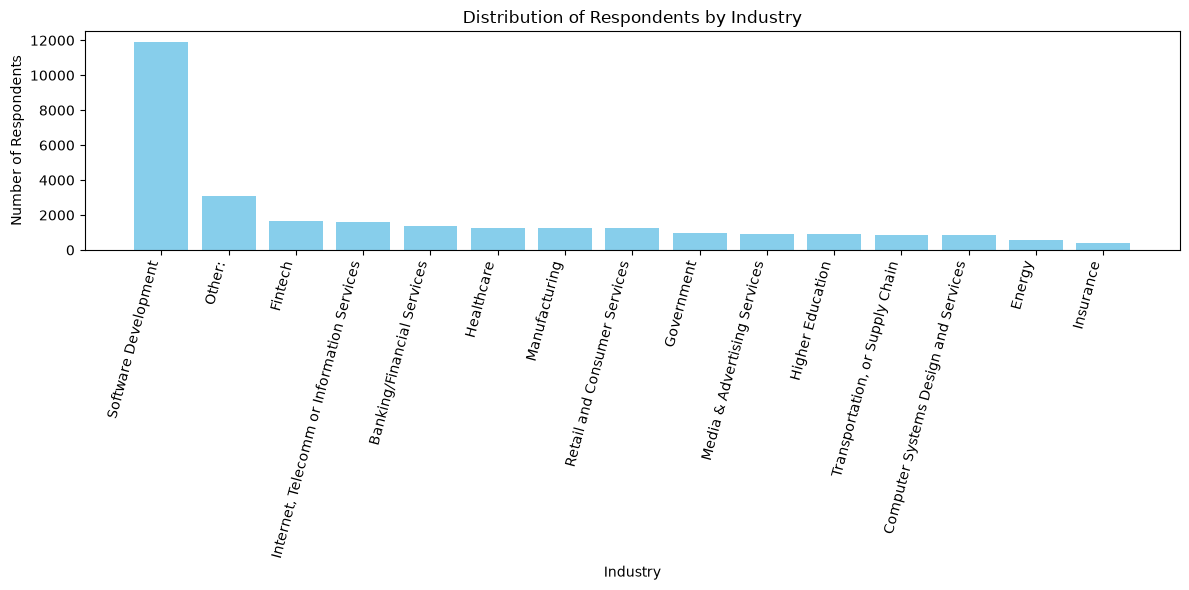

In [3]:
##Write your code here
industry_counts = df["Industry"].value_counts()
plt.figure(figsize=(12,6))
plt.bar(industry_counts.index, industry_counts.values, color='skyblue')
plt.xticks(rotation=75, ha='right')
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Respondents by Industry")
plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
##Write your code here
comp = df["ConvertedCompYearly"].dropna()
mean_comp = comp.mean()
median_comp = comp.median()
std_comp = comp.std()
print("Mean compensation:", mean_comp)
print("Median compensation:", median_comp)
print("Standard deviation:", std_comp)
threshold = mean_comp + 3 * std_comp
print("\nOutlier threshold (mean + 3*std):", threshold)
extreme_earners = df[df["ConvertedCompYearly"] > threshold]
print("\nNumber of extreme earners:", len(extreme_earners))
print(extreme_earners[["ConvertedCompYearly", "Employment", "Country", "Industry"]].head())

Mean compensation: 86155.28726264134
Median compensation: 65000.0
Standard deviation: 186756.97308629754

Outlier threshold (mean + 3*std): 646426.206521534

Number of extreme earners: 89
      ConvertedCompYearly           Employment                   Country  \
529              650000.0  Employed, full-time  United States of America   
828             1000000.0  Employed, full-time  United States of America   
1932             945000.0  Employed, full-time  United States of America   
2171             750000.0  Employed, full-time  United States of America   
2187            2000000.0  Employed, full-time                     Gabon   

                          Industry  
529           Software Development  
828   Retail and Consumer Services  
1932                     Insurance  
2171    Banking/Financial Services  
2187                           NaN  


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower bound: -80177.25
Upper bound: 220860.75
Number of outliers: 978


/tmp/ipykernel_596/3587827039.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(comp, vert=False)


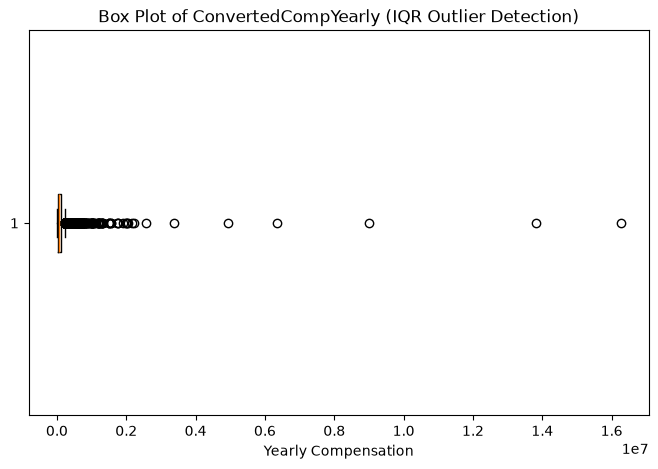

In [5]:
##Write your code here
comp = df["ConvertedCompYearly"].dropna()
Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
outliers = comp[(comp < lower_bound) | (comp > upper_bound)]
print("Number of outliers:", len(outliers))
plt.figure(figsize=(8, 5))
plt.boxplot(comp, vert=False)
plt.title("Box Plot of ConvertedCompYearly (IQR Outlier Detection)")
plt.xlabel("Yearly Compensation")
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [6]:
##Write your code here
comp = df["ConvertedCompYearly"].dropna()
Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_no_outliers = df[(df["ConvertedCompYearly"] >= lower_bound) &
                    (df["ConvertedCompYearly"] <= upper_bound)]
print("Original dataset size:", len(df))
print("Cleaned dataset size:", len(df_no_outliers))
print("Rows removed:", len(df) - len(df_no_outliers))

Original dataset size: 65437
Cleaned dataset size: 22457
Rows removed: 42980


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Unmapped Age values:
Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

Columns in numeric_df:
Index(['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1',
       'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7',
       'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat'],
      dtype='str')

❌ AgeNumeric is NOT in the correlation matrix.


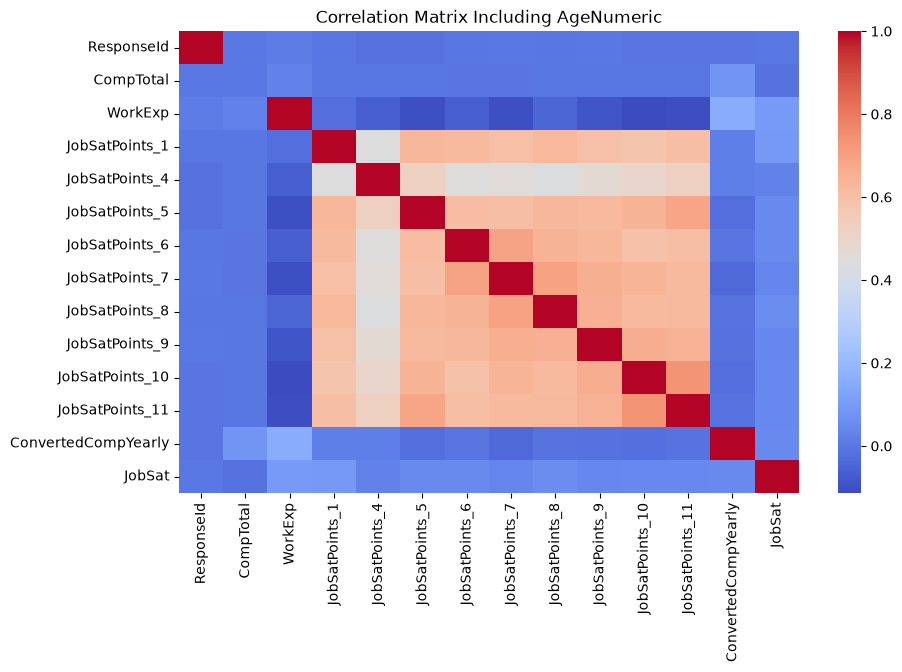

In [7]:
##Write your code here
age_map = {
    "Under 18": 17,
    "18-24": 21,
    "25-34": 29,
    "35-44": 39,
    "45-54": 49,
    "55-64": 59,
    "65 or older": 70
}
df["AgeNumeric"] = df["Age"].map(age_map)
print("Unmapped Age values:")
print(df[df["AgeNumeric"].isna()]["Age"].value_counts())
df["AgeNumeric"] = pd.to_numeric(df["AgeNumeric"], errors="coerce")
numeric_df = df.select_dtypes(include=["int64", "float64"]).copy()
numeric_df["AgeNumeric"] = df["AgeNumeric"]
numeric_df = numeric_df.dropna(axis=1, how="all")
print("\nColumns in numeric_df:")
print(numeric_df.columns)
corr_matrix = numeric_df.corr()
if "AgeNumeric" not in corr_matrix.columns:
    print("\n❌ AgeNumeric is NOT in the correlation matrix.")
else:
    print("\nCorrelation with AgeNumeric:")
    print(corr_matrix["AgeNumeric"].sort_values(ascending=False))
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix Including AgeNumeric")
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
